Brandon Yeu
Variational Autoencoders

1. Why is the KL Divergence term important in the VAE loss function?

- The KL Divergence term acts as a regularizer that constrains the learned latent distribution to be close to a standard Gaussian distribution. Without the KL Divergence term, the encoder could map each input to disjoint regions in latent space, turning the VAE into a deterministic autoencoder. By penalizing deviation from the prior, the KL Divergence term keeps the latent space structured and continuous, which supports meaningful generation and sampling.

2. How does the reparameterization trick enable backpropagation through the stochastic layers of a VAE?

- The reparameterization trick separates randomness from the model parameters. It transforms the sampling into a differentiable function: 𝑧 = 𝜇 + 𝜎.𝜖 where 𝜖 ∼ 𝑁 (0, 1). This allows gradients to fflow through the stochastic layer during backpropagation.

3. Why does a VAE use a probabilistic latent space instead of a fixed latent space?

- A probabilistic latent space allows the VAE to model uncertainty and variability in the data. Instead of encoding each input as a single point, the VAE encodes it as a distribution that captures multiple possible latent representations. Using this leads to better generalization, robustness to noise, and the ability to generate diverse samples. It also prevents overfitting by avoiding precise encodings.

4. What role does KL Divergence play in ensuring a smooth latent space?

- KL Divergence encourages latent distributions for different inputs to overlap and remain close to the prior, which prevents the latent space from splitting into isolated regions and ensures that nearby points in latent space will decode similarly. This means that transitions in latent space are smooth and random samples from the prior produce meaningful outputs.

In [1]:
# !pip install torch
# !pip install torchvision

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [3]:
# VAE Architecture
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h2 = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h2))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [4]:
# Loss function
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [5]:
# Training the VAE
def train(model, train_loader, optimizer, epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    print(f'Epoch {epoch}, Loss: {train_loss / len(train_loader.dataset)}')

In [6]:
# Load MNIST dataset and run the training
transform = transforms.ToTensor()
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

vae = VAE(input_dim=784, hidden_dim=400, latent_dim=20)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(1, 11):
    train(vae, train_loader, optimizer, epoch)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.57MB/s]


Epoch 1, Loss: 163.4235474283854
Epoch 2, Loss: 121.37749518229167
Epoch 3, Loss: 114.4979828938802
Epoch 4, Loss: 111.56040966796876
Epoch 5, Loss: 109.81357618815105
Epoch 6, Loss: 108.62881106770833
Epoch 7, Loss: 107.77183792317709
Epoch 8, Loss: 107.12627330729167
Epoch 9, Loss: 106.60469739583333
Epoch 10, Loss: 106.17297739257812


In [7]:
import matplotlib.pyplot as plt

# Function to generate and display new images
def generate_images(model, num_images=10, latent_dim=20):
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # Turn off gradients for generation
        # Sample random points from the latent space (standard normal distribution)
        z = torch.randn(num_images, latent_dim)
        # Decode these points to generate images
        generated_images = model.decode(z).cpu()

    # Plot the generated images
    fig, axs = plt.subplots(1, num_images, figsize=(num_images, 1.5))
    for i in range(num_images):
        axs[i].imshow(generated_images[i].view(28, 28), cmap='gray')
        axs[i].axis('off')
    plt.show()

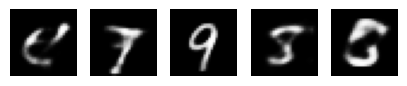

In [8]:
# Assuming you have already trained the model (vae) and it has a latent dimension of 20
generate_images(vae, num_images=5, latent_dim=20)

In [9]:
# Task 1
import torch.nn.functional as F

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        # Decoder
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc(z)
        h = h.view(-1, 128, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_data = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

model = ConvVAE(latent_dim=128)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, 21):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}, Loss: {total_loss / len(train_loader.dataset)}")



100%|██████████| 170M/170M [00:02<00:00, 73.8MB/s]


Epoch 1, Loss: 1930.96005375
Epoch 2, Loss: 1847.8937515625
Epoch 3, Loss: 1834.48173125
Epoch 4, Loss: 1829.79409625
Epoch 5, Loss: 1826.9487065625
Epoch 6, Loss: 1824.9902771875
Epoch 7, Loss: 1823.7074725
Epoch 8, Loss: 1822.6165053125
Epoch 9, Loss: 1821.7883675
Epoch 10, Loss: 1821.1127734375
Epoch 11, Loss: 1820.6264309375
Epoch 12, Loss: 1820.3229278125
Epoch 13, Loss: 1819.7222
Epoch 14, Loss: 1819.2620453125
Epoch 15, Loss: 1819.072525625
Epoch 16, Loss: 1818.6367240625
Epoch 17, Loss: 1818.4723490625
Epoch 18, Loss: 1818.1469375
Epoch 19, Loss: 1817.8246578125
Epoch 20, Loss: 1817.8350903125


##Analysis
The results of the fully connected VAE seem random, whereas the results of the VAE that uses convolutional layers clearly show an iterative process. Each image, we can see the small transformations that occur to get from one image to the next.

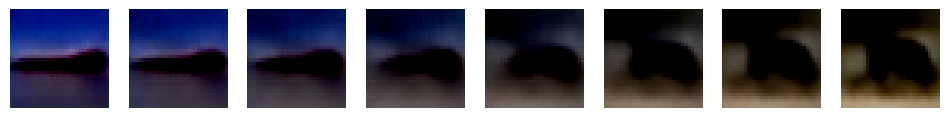

In [13]:
# Task 2

import numpy as np
import matplotlib.pyplot as plt

def interpolate(model, img1, img2, steps=10):
    model.eval()
    with torch.no_grad():
        mu1, _ = model.encode(img1.unsqueeze(0))
        mu2, _ = model.encode(img2.unsqueeze(0))

        interpolations = []
        for alpha in np.linspace(0, 1, steps):
            z = (1 - alpha) * mu1 + alpha * mu2
            interpolations.append(model.decode(z).squeeze(0))

    return interpolations

imgs, _ = next(iter(train_loader))
interp_imgs = interpolate(model, imgs[0], imgs[1], steps=8)

plt.figure(figsize=(12,2))
for i, img in enumerate(interp_imgs):
    plt.subplot(1, 8, i+1)
    plt.imshow(img.permute(1,2,0))
    plt.axis('off')
plt.show()


Using device: cpu


100%|██████████| 182M/182M [00:11<00:00, 15.2MB/s]


Epoch 01 | Loss: 1955.7851
Epoch 02 | Loss: 1918.0484
Epoch 03 | Loss: 1914.2588
Epoch 04 | Loss: 1912.7234
Epoch 05 | Loss: 1911.5311
Epoch 06 | Loss: 1910.8133
Epoch 07 | Loss: 1910.0649
Epoch 08 | Loss: 1909.5197
Epoch 09 | Loss: 1909.1468
Epoch 10 | Loss: 1908.6715


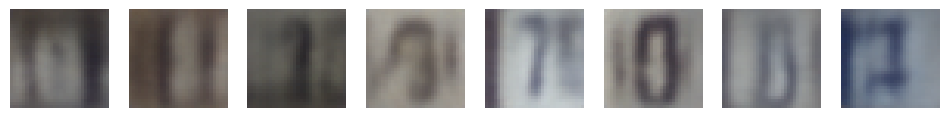

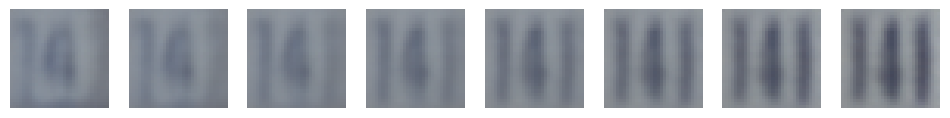

In [27]:
#Task 3

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.ToTensor()

dataset = datasets.SVHN(
    root="./data",
    split="train",
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=128, shuffle=True)

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        # Decoder
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc(z)
        h = h.view(-1, 128, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl
model = ConvVAE(latent_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train(model, loader, optimizer, epoch):
    model.train()
    total_loss = 0

    for x, _ in loader:
        x = x.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader.dataset)
    print(f"Epoch {epoch:02d}, Loss: {total_loss / len(train_loader.dataset)}")
for epoch in range(1, 11):
    train(model, loader, optimizer, epoch)

def generate_images(model, latent_dim=128, num_images=8):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_images, latent_dim).to(device)
        samples = model.decode(z).cpu()

    plt.figure(figsize=(12, 2))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(samples[i].permute(1, 2, 0))
        plt.axis("off")
    plt.show()
generate_images(model)
def interpolate(model, img1, img2, steps=8):
    model.eval()
    with torch.no_grad():
        img1 = img1.unsqueeze(0).to(device)
        img2 = img2.unsqueeze(0).to(device)

        mu1, _ = model.encode(img1)
        mu2, _ = model.encode(img2)

        images = []
        for alpha in np.linspace(0, 1, steps):
            z = (1 - alpha) * mu1 + alpha * mu2
            images.append(model.decode(z).cpu())

    return images
imgs, _ = next(iter(loader))
interp_imgs = interpolate(model, imgs[0], imgs[1])

plt.figure(figsize=(12, 2))
for i, img in enumerate(interp_imgs):
    plt.subplot(1, len(interp_imgs), i + 1)
    plt.imshow(img.squeeze(0).permute(1, 2, 0))
    plt.axis("off")
plt.show()


In [28]:
def sample_latent_region(model, latent_dim=128, num_images=8, scale=1.0):
    model.eval()
    with torch.no_grad():
        z = scale * torch.randn(num_images, latent_dim).to(device)
        samples = model.decode(z).cpu()
    return samples


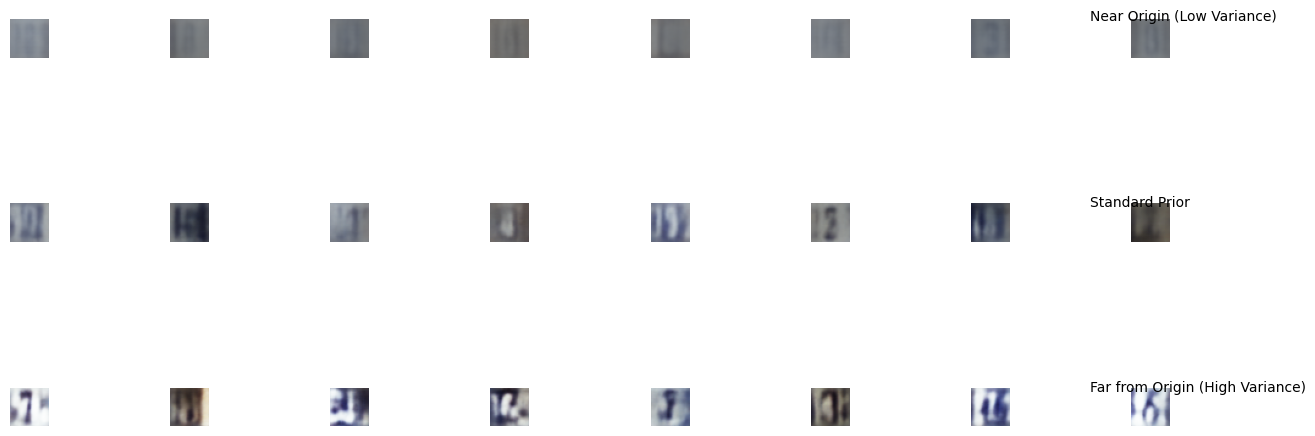

In [29]:
def visualize_latent_regions(model, latent_dim=128):
    scales = [0.3, 1.0, 2.0]
    titles = ["Near Origin (Low Variance)", "Standard Prior", "Far from Origin (High Variance)"]

    plt.figure(figsize=(12, 6))

    for row, (scale, title) in enumerate(zip(scales, titles)):
        samples = sample_latent_region(model, latent_dim, num_images=8, scale=scale)

        for col in range(8):
            idx = row * 8 + col + 1
            plt.subplot(3, 8, idx)
            plt.imshow(samples[col].permute(1, 2, 0))
            plt.axis("off")

        plt.text(-35, row * 1.1 + 0.5, title, fontsize=10)

    plt.tight_layout()
    plt.show()
visualize_latent_regions(model)


##Analysis
Sampling near the origin of the latent space produces images that are smoother and generally more representative of the average training data, while sampling from the standard prior generates diverse, but still understandable images. Sampling far from the origin produces images that are appear distorted.